# PyFock tutorial and demo notebook

This notebook is designed as a practical introduction to PyFock that can be run on Colab, Kaggle, or a local machine. It follows the example scripts in the repository, but presents them as a single guided workflow.

What we cover:

- installation and setup,
- creation of XYZ files inside the notebook,
- the `Basis` API,
- the `Mol` API,
- one- and two-electron integrals,
- XC grids, AO values, AO gradients, and densities on grids,
- DFT in PyFock,
- optional advanced topics: PySCF grids, LibXC, GPU usage, cube files, gradients, ASE optimization, and TDHF-TDA.

Heavy calculations are clearly marked as optional.

## 1. Install PyFock

The notebook starts with a standard `pip` install so it also works outside this repository checkout.

In [1]:
!pip install pyfock

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.3/20.3 MB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 48.7 MB/s eta 0:00:00


Optional extras used later in the notebook:

- `pyscf` for PySCF grids,
- `matplotlib` for plotting the TDHF-TDA spectrum,
- `ase` for geometry optimization,
- `pylibxc` for LibXC-backed XC evaluation.

Uncomment only what you need.

In [2]:
!pip install pyscf matplotlib ase

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 MB 37.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 97.9 MB/s eta 0:00:00


Import useful modules like Integrals, Utils, XC, Basis, DFT and so on

In [ ]:
import numpy as np

import pyfock.Integrals as Integrals
import pyfock.Utils as Utils
import pyfock.XC as XC
from pyfock import Basis, DFT, DFT_Grad, DFT_NumGrad, Grids, Mol, PyFockCalculator

## 2. Create molecule files inside the notebook

To keep the notebook self-contained, we create the XYZ files used later here instead of assuming they already exist in the working directory.

In [4]:
h2o_xyz = """
3
water
O   1.5317501102751168   0.005922000426339914   -0.12088000870249964
H   0.5759680414656068  -0.005249000377890358    0.024966001797376243
H   1.9062491372363866  -0.037561002704125934    0.7632180549462737
"""

decane_xyz = """
32
decane
C    0.660900    0.387900    0.066100
C   -0.642900   -0.416100    0.097200
C    1.914100   -0.489400    0.024000
C   -1.896200    0.462500    0.063500
C    3.185800    0.361800    0.007100
C   -3.199200   -0.343000    0.034200
C    4.438100   -0.511000   -0.073500
C   -4.449800    0.530500   -0.074800
C    5.705000    0.329500   -0.056800
C   -5.715800   -0.312900   -0.087000
H    0.654500    1.046100   -0.811600
H    0.700300    1.037900    0.949000
H   -0.661800   -1.040700    0.998600
H   -0.661600   -1.098500   -0.761600
H    1.926200   -1.154000    0.896400
H    1.883700   -1.126300   -0.868200
H   -1.899000    1.124300    0.938300
H   -1.856400    1.108400   -0.822400
H    3.160900    1.045500   -0.850300
H    3.224700    0.980000    0.912300
H   -3.172100   -1.037400   -0.814900
H   -3.260200   -0.955900    0.942100
H    4.460200   -1.209400    0.771100
H    4.415400   -1.111100   -0.990500
H   -4.488700    1.228900    0.769100
H   -4.405200    1.129900   -0.991300
H    6.587900   -0.314500   -0.116200
H    5.774200    0.916700    0.864500
H    5.729400    1.019000   -0.906700
H   -6.598200    0.329900   -0.165500
H   -5.720200   -1.001500   -0.937900
H   -5.804400   -0.900800    0.832000
"""

caffeine_xyz = """
24
1,3,7-Trimethylpurine-2,6-dione
N          1.58080        0.70270       -0.22790
C          1.70620       -0.73740       -0.21260
N          0.53400       -1.56710       -0.35030
C          0.32310        1.36000        0.02740
C         -0.81230        0.45530        0.08170
C         -0.69670       -0.93220       -0.06620
N         -2.18860        0.69900        0.27830
C         -2.85120       -0.52050        0.25320
N         -1.95370       -1.51880        0.04260
C          0.65680       -3.02740       -0.16750
O          2.81360       -1.25580       -0.16930
O          0.28490        2.57440        0.15910
C         -2.80960        2.00310        0.50320
C          2.83010        1.50040       -0.19680
H         -3.92710       -0.67870        0.37620
H          1.48230       -3.40460       -0.78650
H         -0.27080       -3.52040       -0.48680
H          0.85670       -3.29900        0.87880
H         -2.41230        2.74780       -0.20170
H         -2.60420        2.36210        1.52210
H         -3.89730        1.93440        0.36950
H          3.59590        1.03330       -0.83140
H          3.22490        1.57910        0.82550
H          2.64310        2.51300       -0.57930
"""



def write_text_file(filename, text):
    open(filename, "w", encoding="utf-8").write(text.strip() + "\n")

write_text_file("h2o.xyz", h2o_xyz)
write_text_file("decane.xyz", decane_xyz)
write_text_file("caffeine.xyz", caffeine_xyz)


Check if the files now exist in the working directory

In [5]:
!ls

caffeine.xyz  decane.xyz  h2o.xyz  __notebook__.ipynb


## 3. Basis API

A Cartesian primitive Gaussian centered at $\mathbf{A}$ is

$$
\chi_{\alpha,lmn}(\mathbf{r};\mathbf{A}) = N_{\alpha,lmn}\,(x-A_x)^l(y-A_y)^m(z-A_z)^n e^{-\alpha |\mathbf{r}-\mathbf{A}|^2}.
$$

A contracted basis function is a linear combination of primitives:

$$
\phi_\mu(\mathbf{r}) = N_\mu \sum_k d_{\mu k}\,\chi_{\alpha_k,lmn}(\mathbf{r};\mathbf{A}).
$$

For Cartesian Gaussians, the primitive normalization factor is

$$
N_{\alpha,lmn} = \left(\frac{2\alpha}{\pi}\right)^{3/4}
\left(\frac{(4\alpha)^{l+m+n}}{(2l-1)!!(2m-1)!!(2n-1)!!}\right)^{1/2}.
$$

The contraction normalization factor $N_\mu$ is chosen so that

$$
\langle \phi_\mu | \phi_\mu \rangle = 1.
$$

PyFock stores the primitive normalization factors and the contraction normalization factors in the `Basis` object.

In [6]:
mol_h2o = Mol(coordfile=str("h2o.xyz"))

# Create a custom basis set in Turbomole format as a multi-line string.
sto3g_tm = """
*
*
o STO-3G
*
3   s
0.1307093214E+03       0.1543289673E+00
0.2380886605E+02       0.5353281423E+00
0.6443608313E+01       0.4446345422E+00
3   s
0.5033151319E+01      -0.9996722919E-01
0.1169596125E+01       0.3995128261E+00
0.3803889600E+00       0.7001154689E+00
3   p
0.5033151319E+01       0.1559162750E+00
0.1169596125E+01       0.6076837186E+00
0.3803889600E+00       0.3919573931E+00
*
*
h STO-3G
*
3   s
0.3425250914E+01       0.1543289673E+00
0.6239137298E+00       0.5353281423E+00
0.1688554040E+00       0.4446345422E+00
*
"""
write_text_file("sto-3g.dat", sto3g_tm) # Create a file with the custom basis set for loading in the step 2.

# 1. Load a custom basis directly from a Turbomole-format string.
basis_from_string = Basis(mol_h2o, {"all": sto3g_tm})
print("Custom basis from string")
print("NAO:", basis_from_string.bfs_nao)
print("Total primitives:", basis_from_string.totalnprims)
print("First few contraction normalization factors:")
print(basis_from_string.bfs_contr_prim_norms[:5])

# 2. Load the same basis from a file created inside this notebook.
basis_from_file = Basis(mol_h2o, {"all": Basis.loadfromfile(mol=mol_h2o, basis_name=str("sto-3g.dat"))})
print("\nBasis loaded from file")
print("NAO:", basis_from_file.bfs_nao)

# 3. Load a built-in basis from PyFock.
basis_builtin = Basis(mol_h2o, {"all": Basis.load(mol=mol_h2o, basis_name="def2-SVP")})
print("\nBuilt-in basis from the PyFock basis library")
print("NAO:", basis_builtin.bfs_nao)
print("Shell labels:", basis_builtin.shellsLabel)

Custom basis from string
NAO: 7
Total primitives: 15
First few contraction normalization factors:
[np.float64(0.9999999999757437), np.float64(0.9999999999837428), np.float64(1.0000000000099754), np.float64(1.0000000000099754), np.float64(1.0000000000099754)]

Basis loaded from file
NAO: 7

Built-in basis from the PyFock basis library
NAO: 25
Shell labels: ['s', 's', 's', 'p', 'p', 'd', 's', 's', 'p', 's', 's', 'p']


In [7]:
print("Selected Basis attributes for def2-SVP on H2O")
print("bfs_nao:", basis_builtin.bfs_nao)
print("totalnprims:", basis_builtin.totalnprims)
print("nprims:", basis_builtin.nprims)
print("alpha_max:", basis_builtin.alpha_max)
print("alpha_min:", basis_builtin.alpha_min)
print("first 6 bfs labels:", basis_builtin.bfs_label[:6])
print("first 6 bfs lmn tuples:", basis_builtin.bfs_lmn[:6])
print("first 6 bfs shell indices:", basis_builtin.bfs_shell_index[:6])
print("first 3 bfs primitive exponents:")
for i in range(3):
    print(i, basis_builtin.bfs_expnts[i])
print("first 3 bfs primitive coeffs:")
for i in range(3):
    print(i, basis_builtin.bfs_coeffs[i])

Selected Basis attributes for def2-SVP on H2O
bfs_nao: 25
totalnprims: 22
nprims: [5, 1, 1, 3, 1, 1, 3, 1, 1, 3, 1, 1]
alpha_max: [2266.1767785, 13.010701, 13.010701]
alpha_min: [{0: 0.25530772234, 1: 0.27641544411, 2: 1.2}, {0: 0.12194962, 1: 0.8}, {0: 0.12194962, 1: 0.8}]
first 6 bfs labels: ['s', 's', 's', 'px', 'py', 'pz']
first 6 bfs lmn tuples: [[0, 0, 0], [0, 0, 0], [0, 0, 0], [1, 0, 0], [0, 1, 0], [0, 0, 1]]
first 6 bfs shell indices: [0, 1, 2, 3, 3, 3]
first 3 bfs primitive exponents:
0 [2266.1767785, 340.87010191, 77.363135167, 21.47964494, 6.6589433124]
1 [0.80975975668]
2 [0.25530772234]
first 3 bfs primitive coeffs:
0 [-0.0053431809926, -0.03989003923, -0.17853911985, -0.46427684959, -0.44309745172]
1 [1.0]
2 [1.0]


## 4. Mol API

The `Mol` class can be created from an XYZ file or directly from an atom list. It stores atomic species, coordinates in Angstrom and Bohr and helper methods such as dipole-moment utilities and XYZ export.

In [8]:
# Create a molecule object from an XYZ file
mol_from_xyz = Mol(coordfile=str("h2o.xyz"))

# Create a molecule object from an in-memory list of atoms and coordinates
atoms_list = [
    ["O", 1.53175011,  0.00592200, -0.12088001],
    ["H", 0.57596804, -0.00524900,  0.02496600],
    ["H", 1.90624914, -0.03756100,  0.76321805],
]
mol_from_list = Mol(atoms=atoms_list)

print("Molecule from XYZ")
print("natoms:", mol_from_xyz.natoms)
print("charge:", mol_from_xyz.charge)
print("atomicSpecies:", mol_from_xyz.atomicSpecies)
print("Zcharges:", mol_from_xyz.Zcharges)
print("coords (Angstrom):\n", mol_from_xyz.coords)
print("coords (Bohr):\n", mol_from_xyz.coordsBohrs)
print("center of charge (Angstrom):", mol_from_xyz.get_center_of_charge())

print("\nMolecule reconstructed from in-memory atom list")
print("natoms:", mol_from_list.natoms)
print("coords match:", np.allclose(mol_from_xyz.coords, mol_from_list.coords))

mol_from_xyz.exportXYZ(filename="h2o_exported", label="Exported from the PyFock tutorial notebook")
exported_xyz = "h2o_exported.xyz"
print("\nExported XYZ file:", exported_xyz)

Molecule from XYZ
natoms: 3
charge: 0
atomicSpecies: ['O', 'H', 'H']
Zcharges: [8, 1, 1]
coords (Angstrom):
 [[ 1.53175011  0.005922   -0.12088001]
 [ 0.57596804 -0.005249    0.024966  ]
 [ 1.90624914 -0.037561    0.76321805]]
coords (Bohr):
 [[ 2.8945882   0.01119096 -0.22843011]
 [ 1.08842185 -0.00991917  0.04717891]
 [ 3.60228879 -0.07098001  1.4422731 ]]
center of charge (Angstrom): [ 1.47362181e+00  4.56600033e-04 -1.78856013e-02]

Molecule reconstructed from in-memory atom list
natoms: 3
coords match: True

Exported XYZ file: h2o_exported.xyz


## 5. One-electron integrals: overlap, kinetic, and nuclear attraction

The basic one-electron integrals are

$$
S_{\mu\nu} = \langle \phi_\mu | \phi_\nu \rangle,
$$

$$
T_{\mu\nu} = \left\langle \phi_\mu \middle| -\tfrac{1}{2}\nabla^2 \middle| \phi_\nu \right\rangle,
$$

$$
V^{\mathrm{nuc}}_{\mu\nu} = \sum_A -Z_A \left\langle \phi_\mu \middle| \frac{1}{|\mathbf{r}-\mathbf{R}_A|} \middle| \phi_\nu \right\rangle.
$$

These are the building blocks of the core Hamiltonian.

In [9]:
# Helper function to display matrix information in a consistent format
def show_matrix_info(name, arr, rows=5, cols=5):
    arr = np.asarray(arr)
    print(f"{name}: shape={arr.shape}, dtype={arr.dtype}")
    if arr.ndim == 2:
        print(arr[:rows, :cols])
    elif arr.ndim == 3:
        print(arr[:rows, :cols, 0])
    elif arr.ndim == 4:
        print(arr[:rows, :cols, 0, 0])
    else:
        print(arr)

Now we define a mol and basis object and use those to evaluate one electron integrals.
NOTE: The first run to evaluate these will take some time as they get compiled during the first run (see NUMBA's just-in-time or JIT compilation)

In [10]:
# Create a molecule object for H2O to use in the integral calculations.
mol_h2o = Mol(coordfile=str("h2o.xyz"))

# Create a basis set for H2O using the built-in def2-SVP basis from PyFock.
basis = Basis(mol_h2o, {"all": Basis.load(mol=mol_h2o, basis_name="def2-SVP")})

S = Integrals.overlap_mat_symm(basis) # Overlap matrix
T = Integrals.kin_mat_symm(basis) # Kinetic energy matrix
Vnuc = Integrals.nuc_mat_symm(basis, mol_h2o) # Nuclear attraction matrix


# Print out the shapes, dtypes, and first few elements of the integral matrices to verify they were computed correctly.
show_matrix_info("S", S)
show_matrix_info("T", T)
show_matrix_info("V_nuc", Vnuc)

# Now we will compute the same integrals but only for a block of the basis functions 
# (e.g. the first 4 basis functions) and verify that they match the corresponding block 
# in the full integral matrices.
S_block = Integrals.overlap_mat_symm(basis, slice=[0, 4, 0, 4])
T_block = Integrals.kin_mat_symm(basis, slice=[0, 4, 0, 4])
Vnuc_block = Integrals.nuc_mat_symm(basis, mol_h2o, slice=[0, 4, 0, 4])

print("S block agrees with the full matrix:", np.allclose(S_block, S[0:4, 0:4]))
print("T block agrees with the full matrix:", np.allclose(T_block, T[0:4, 0:4]))
print("V_nuc block agrees with the full matrix:", np.allclose(Vnuc_block, Vnuc[0:4, 0:4]))

S: shape=(25, 25), dtype=float64
[[ 1.00000000e+00 -3.44016554e-01 -1.57870042e-01  1.37269736e-16
  -1.18193426e-18]
 [-3.44016554e-01  1.00000000e+00  7.88940794e-01  3.83229401e-16
   2.39124837e-19]
 [-1.57870042e-01  7.88940794e-01  1.00000000e+00 -1.67919546e-16
   1.86246968e-18]
 [ 1.37269736e-16  3.83229401e-16 -1.67919546e-16  1.00000000e+00
   0.00000000e+00]
 [-1.18193426e-18  2.39124837e-19  1.86246968e-18  0.00000000e+00
   1.00000000e+00]]
T: shape=(25, 25), dtype=float64
[[ 2.93566544e+01 -7.68111872e-01 -1.17549362e-01 -1.35968525e-15
   2.71765835e-17]
 [-7.68111872e-01  1.21463964e+00  4.59418717e-01  1.10464839e-15
   5.38595004e-19]
 [-1.17549362e-01  4.59418717e-01  3.82961584e-01 -1.13682272e-16
   1.48362211e-18]
 [-1.35968525e-15  1.10464839e-15 -1.13682272e-16  4.33232659e+00
   0.00000000e+00]
 [ 2.71765835e-17  5.38595004e-19  1.48362211e-18  0.00000000e+00
   4.33232659e+00]]
V_nuc: shape=(25, 25), dtype=float64
[[-6.23818254e+01  1.18830220e+01  5.24979186

Try running the above block again and notice that the second run is now significantly faster as the previously run code is now compiled and cached.

## 6. Electron-repulsion integrals (ERIs)

The four-center two-electron Coulomb integral is

$$
(\mu\nu|\lambda\sigma)=\iint \frac{\phi_\mu(\mathbf{r}_1)\phi_\nu(\mathbf{r}_1)\phi_\lambda(\mathbf{r}_2)\phi_\sigma(\mathbf{r}_2)}{|\mathbf{r}_1-\mathbf{r}_2|} \, d\mathbf{r}_1 d\mathbf{r}_2.
$$

PyFock provides several ways to evaluate ERIs:

- conventional explicit formulas,
- Rys quadrature,
- Obara-Saika (OS).

For density fitting, the related three-center and two-center quantities are

$$
(\mu\nu|P)=\iint \frac{\phi_\mu(\mathbf{r}_1)\phi_\nu(\mathbf{r}_1)\chi_P(\mathbf{r}_2)}{|\mathbf{r}_1-\mathbf{r}_2|} \, d\mathbf{r}_1 d\mathbf{r}_2,
$$

$$
(P|Q)=\iint \frac{\chi_P(\mathbf{r}_1)\chi_Q(\mathbf{r}_2)}{|\mathbf{r}_1-\mathbf{r}_2|} \, d\mathbf{r}_1 d\mathbf{r}_2.
$$

Schwarz screening uses upper bounds such as

$$
|(\mu\nu|\lambda\sigma)| \le \sqrt{(\mu\nu|\mu\nu)}\sqrt{(\lambda\sigma|\lambda\sigma)}
$$

to skip negligible integrals.

The following block will take quite some time (2 to 10 minutes depending on the machine configuration and NUMBA version) for the first run as here we calculate 4c2e, 3c2e and 2c2e integrals using various algorithms and each one of those will be compiled when run for the first time. The second run will be much faster.

In [11]:
basis = Basis(mol_h2o, {"all": Basis.load(mol=mol_h2o, basis_name="def2-SVP")})
auxbasis = Basis(mol_h2o, {"all": Basis.load(mol=mol_h2o, basis_name="def2-universal-jfit")})

ERI_conv = Integrals.conv_4c2e_symm(basis)
show_matrix_info("ERI conventional", ERI_conv)
ERI_rys = Integrals.rys_4c2e_symm(basis)
show_matrix_info("ERI Rys", ERI_rys)
ERI_os = Integrals.os_4c2e_symm(basis)
show_matrix_info("ERI OS", ERI_os)

print("max|conv - rys| =", np.max(np.abs(ERI_conv - ERI_rys)))
print("max|rys - os|   =", np.max(np.abs(ERI_rys - ERI_os)))

ERI_rys_screened = Integrals.rys_4c2e_schwarz_symm(basis, threshold_schwarz=1e-9)
print("max|rys - rys_screened| =", np.max(np.abs(ERI_rys - ERI_rys_screened)))

ERI3_conv = Integrals.conv_3c2e_symm(basis, auxbasis)
ERI3_rys = Integrals.rys_3c2e_symm(basis, auxbasis)
ERI3_rys_screened = Integrals.rys_3c2e_symm(basis, auxbasis, schwarz=True, threshold_schwarz=1e-9)
ERI3_tri = Integrals.rys_3c2e_tri(basis, auxbasis)
ERI2_conv = Integrals.conv_2c2e_symm(basis)
ERI2_rys = Integrals.rys_2c2e_symm(basis)

show_matrix_info("3c2e conventional", ERI3_conv)
show_matrix_info("3c2e Rys", ERI3_rys)
print("max|3c2e conv - rys| =", np.max(np.abs(ERI3_conv - ERI3_rys)))
print("max|3c2e rys - screened| =", np.max(np.abs(ERI3_rys - ERI3_rys_screened)))
show_matrix_info("3c2e triangular", ERI3_tri)
show_matrix_info("2c2e conventional", ERI2_conv)
show_matrix_info("2c2e Rys", ERI2_rys)
print("max|2c2e conv - rys| =", np.max(np.abs(ERI2_conv - ERI2_rys)))

ERI conventional: shape=(25, 25, 25, 25), dtype=float64
[[ 4.77665645e+00 -1.15239208e+00 -5.13270591e-01  4.36000475e-16
   1.01042849e-18]
 [-1.15239208e+00  1.39854387e+00  9.02678264e-01  6.48684316e-16
   6.93130741e-19]
 [-5.13270591e-01  9.02678264e-01  7.99422640e-01  9.73009869e-17
   2.73576573e-18]
 [ 4.36000475e-16  6.48684316e-16  9.73009869e-17  1.44559235e+00
   1.99757710e-35]
 [ 1.01042849e-18  6.93130741e-19  2.73576573e-18  1.99757710e-35
   1.44559235e+00]]
ERI Rys: shape=(25, 25, 25, 25), dtype=float64
[[ 4.77665645 -1.15239208 -0.51327059  0.          0.        ]
 [-1.15239208  1.39854387  0.90267826  0.          0.        ]
 [-0.51327059  0.90267826  0.79942264  0.          0.        ]
 [ 0.          0.          0.          1.44559235  0.        ]
 [ 0.          0.          0.          0.          1.44559235]]
ERI OS: shape=(25, 25, 25, 25), dtype=float64
[[ 4.77665645 -1.15239208 -0.51327059  0.          0.        ]
 [-1.15239208  1.39854387  0.90267826  0.     

Run the above block again to see the significant speed difference (it will run instantly) compared to the first run.

## 7. System information, XC grids, AO values, AO gradients, and densities

These examples provide the numerical ingredients needed for DFT: grids, AO values on those grids, AO gradients, and electron density values.

In [12]:
# Helper function to display system information like CPU model, number of cores, and memory.
Utils.print_sys_info()
print("CPU model:", Utils.get_cpu_model())

# Create a basis object for H2O using the built-in def2-SVP basis from PyFock to use in the grid and AO value calculations.
basis = Basis(mol_h2o, {"all": Basis.load(mol=mol_h2o, basis_name="def2-SVP")})

# Generate a numerical integration grid for H2O using the built-in grid generator in PyFock. 
# We will use a medium level of grid density (level=3) and specify ncores=2 to use 2 CPU cores for grid generation.
grids = Grids(mol_h2o, basis=basis, level=3, ncores=2)
print("Number of grid points:", grids.coords.shape[0])
print("First five grid weights:", grids.weights[:5])
print("First five grid coordinates:\n", grids.coords[:5])

# Calculate the AO values and gradients on the grid points using the helper functions in PyFock.
ao_values = Integrals.bf_val_helpers.eval_bfs(basis, grids.coords, parallel=True)
ao_values2, ao_grad_values = Integrals.bf_val_helpers.eval_bfs_and_grad(basis, grids.coords, parallel=True)
print("AO value array shape:", ao_values.shape)
print("AO gradient array shape:", ao_grad_values.shape)

# Calculate the electron density on the grid points using the AO values 
# and a guess density matrix (e.g. from a simple DFT guess) and 
# compare it to the density calculated using the helper function in PyFock 
# that directly computes the density from the AO values and density matrix.
dft_guess = DFT(mol_h2o, basis, xc="PBE")
dmat_guess = dft_guess.guessCoreH()
rho_from_ao = np.einsum("ij,mi,mj->m", dmat_guess, ao_values, ao_values)
rho_helper = Integrals.bf_val_helpers.eval_rho(ao_values, dmat_guess)
print("max|rho_direct - rho_helper| =", np.max(np.abs(rho_from_ao - rho_helper)))

print("First five density values:", rho_helper[:5])

rho_test = np.array([0.5, 1.0, 2.0], dtype=np.float64)
print("\nPyFock XC evaluation example")
for label in ["LDA", "PBE"]:
    func_ids = XC.resolve_functional(label)
    print(label, "->", func_ids)


============= System Information =============
Operating System: Linux 6.6.122+
System Type: 64bit
CPU Model: Intel(R) Xeon(R) CPU @ 2.00GHz
Number of Cores: 2
Number of Threads: 4
Memory (GB): 31.35
CPU model: Intel(R) Xeon(R) CPU @ 2.00GHz
Grid generation using 2 threads for Joblib.
Number of grid points: 88446
First five grid weights: [1.12036705e-19 1.12036705e-19 1.12036705e-19 1.12036705e-19
 1.12036705e-19]
First five grid coordinates:
 [[ 2.8945895   0.01119096 -0.22843011]
 [ 2.8945869   0.01119096 -0.22843011]
 [ 2.8945882   0.01119226 -0.22843011]
 [ 2.8945882   0.01118966 -0.22843011]
 [ 2.8945882   0.01119096 -0.22842881]]
AO value array shape: (88446, 25)
AO gradient array shape: (3, 88446, 25)
max|rho_direct - rho_helper| = 2.1024317220508237e-07
First five density values: [327.33372728 327.33373346 327.33373007 327.33373067 327.33373608]

PyFock XC evaluation example
LDA -> [1, 7]
PBE -> [101, 130]


## 8. DFT API: a basic PBE calculation on water and Dipole moment

We now run a basic DFT calculation on H$_2$O using the PBE functional. We modify `ncores`, `conv_crit`, and `max_itr` after constructing the `DFT` object.

NOTE: The first run, as usual, is expected to be slower. Subsequent runs would be much faster as they employ cached and compiled code.

In [13]:
# Create a mol object
mol_h2o = Mol(coordfile=str("h2o.xyz"))
# Create a basis object
basis_dft = Basis(mol_h2o, {"all": Basis.load(mol=mol_h2o, basis_name="def2-SVP")})
# Create an auxiliary basis for density fitting
auxbasis_dft = Basis(mol_h2o, {"all": Basis.load(mol=mol_h2o, basis_name="def2-universal-jfit")})

# Create a DFT object
dft_h2o = DFT(mol_h2o, basis_dft, auxbasis_dft, xc="PBE")
dft_h2o.ncores = 2 # Specify the number of CPU cores to use for parallel computations in the DFT calculation.
dft_h2o.conv_crit = 1e-7 # Set the convergence criterion for the SCF procedure to 1e-7 Hartree.
dft_h2o.max_itr = 20 # Set the maximum number of SCF iterations to 20.

energy_h2o, dmat_h2o = dft_h2o.scf() # Run the SCF procedure
print("Total energy (Ha):", energy_h2o)
print("Converged:", dft_h2o.converged)
print("Iterations:", dft_h2o.niter)
print("Density matrix shape:", dmat_h2o.shape)

# Calculate the dipole moment matrix
dipole_mat = Integrals.dipole_moment_mat_symm(basis_dft)
# Calculate the nuclear, electronic, and total dipole moments using the helper functions in PyFock and print the results.
mu_nuc = mol_h2o.get_nuc_dip_moment()
mu_elec = mol_h2o.get_elec_dip_moment(dipole_mat, dmat_h2o)
mu_tot = mol_h2o.get_dipole_moment(dipole_mat, dmat_h2o)
print("Nuclear dipole (a.u.):", mu_nuc)
print("Electronic dipole (a.u.):", mu_elec)
print("Total dipole (a.u.):", mu_tot)


PyFock Python Program for Quantum Chemistry Simulations
                                        by Manas Sharma
██████  ██    ██ ███████  ██████   ██████ ██   ██
██░░░██ ░██  ██░ ██░░░░░ ██░░░░██ ██░░░░░ ██  ██░ 
██████   ░████░  █████   ██    ██ ██      █████░  
██░░░░    ░██░   ██░░░   ██    ██ ██      ██░░██ 
██         ██    ██      ░██████░ ░██████ ██  ░██
░░         ░░    ░░       ░░░░░░   ░░░░░░ ░░   ░░


Version:  0.1.4
Citation: M. Sharma and M. Sierka, PyFock: A Just-In-Time Compiled 
Gaussian Basis DFT Python Code for CPU and GPU Architectures


📧 Contact Information:
   Developer: Dr. Manas Sharma (PhD Physics)
   Email: manas.sharma@uni-jena.de
   Website: https://manas.bragitoff.com/

📚 Resources:
   Documentation: https://pyfock-docs.bragitoff.com
   Official Website: https://pyfock.bragitoff.com/
   GitHub Repo: https://github.com/manassharma07/pyfock
   Web GUI: https://pyfock-gui.bragitoff.com/




 Time to get inspired by a great quantum chemist :)


 ____       _  

Run the above block again and use that to infer idea about the speed of PyFock.

## 9. AO caching, SAO, and PySCF grids

PyFock can cache AO values on quadrature grids to accelerate repeated XC evaluations. This is useful for larger molecules such as decane.

It can also switch from Cartesian AOs (CAOs, such as 6d and 10f) to spherical AOs (SAOs, such as 5d and 7f) through `dftObj.sao = True`.

Finally, if PySCF is installed, PyFock can use PySCF-generated grids internally via `use_pyscf_grids=True`.

NOTE: Grids generated by PyFock depend on the numgrid library, which is slightly slow and also produces quite dense grids. On the other hand, the grids generated by PySCF are much optimal. Therefore, the last run would be  faster due to the faster XC term evaluation.

In [14]:
mol_decane = Mol(coordfile="decane.xyz")
basis_decane = Basis(mol_decane, {"all": Basis.load(mol=mol_decane, basis_name="def2-SVP")})
auxbasis_decane = Basis(mol_decane, {"all": Basis.load(mol=mol_decane, basis_name="def2-universal-jfit")})

print("Decane setup")
print("natoms:", mol_decane.natoms)
print("NAO (CAO):", basis_decane.bfs_nao)


dft_decane_cache = DFT(mol_decane, basis_decane, auxbasis_decane, xc="PBE")
dft_decane_cache.ncores = 2
dft_decane_cache.conv_crit = 1e-6
dft_decane_cache.max_itr = 25
dft_decane_cache.save_ao_values = True
energy_decane_cache, _ = dft_decane_cache.scf()
print("Energy (Ha):", energy_decane_cache)

# Since we are switching to SAO representation, the SAO integral routines will have 
# to be compiled for the first run so the first run is expected to be slow.
dft_decane_sao = DFT(mol_decane, basis_decane, auxbasis_decane, xc="PBE")
dft_decane_sao.ncores = 2
dft_decane_sao.conv_crit = 1e-6
dft_decane_sao.max_itr = 25
dft_decane_sao.save_ao_values = True
dft_decane_sao.sao = True
energy_decane_sao, _ = dft_decane_sao.scf()
print("Energy (Ha):", energy_decane_sao)


# The following DFT run is expected to be the fastest as everything has already 
# compiled by the previous runs, and we are using the more optimal grids generated by PySCF
dft_decane_pyscf_grids = DFT(mol_decane, basis_decane, auxbasis_decane, xc="PBE", use_pyscf_grids=True, gridsLevel=3)
dft_decane_pyscf_grids.ncores = 2
dft_decane_pyscf_grids.conv_crit = 1e-6
dft_decane_pyscf_grids.max_itr = 25
dft_decane_pyscf_grids.save_ao_values = True
energy_pyscf_grids, _ = dft_decane_pyscf_grids.scf()
print("\nPBE with PySCF grids (Ha):", energy_pyscf_grids)

Decane setup
natoms: 32
NAO (CAO): 260

PyFock Python Program for Quantum Chemistry Simulations
                                        by Manas Sharma
██████  ██    ██ ███████  ██████   ██████ ██   ██
██░░░██ ░██  ██░ ██░░░░░ ██░░░░██ ██░░░░░ ██  ██░ 
██████   ░████░  █████   ██    ██ ██      █████░  
██░░░░    ░██░   ██░░░   ██    ██ ██      ██░░██ 
██         ██    ██      ░██████░ ░██████ ██  ░██
░░         ░░    ░░       ░░░░░░   ░░░░░░ ░░   ░░


Version:  0.1.4
Citation: M. Sharma and M. Sierka, PyFock: A Just-In-Time Compiled 
Gaussian Basis DFT Python Code for CPU and GPU Architectures


📧 Contact Information:
   Developer: Dr. Manas Sharma (PhD Physics)
   Email: manas.sharma@uni-jena.de
   Website: https://manas.bragitoff.com/

📚 Resources:
   Documentation: https://pyfock-docs.bragitoff.com
   Official Website: https://pyfock.bragitoff.com/
   GitHub Repo: https://github.com/manassharma07/pyfock
   Web GUI: https://pyfock-gui.bragitoff.com/




 Time to get inspired by a gre

## 10. Native XC Functionals implemented in PyFock

PyFock supports several XC shorthands directly. These are resolved to LibXC-style integer IDs internally. This does **not** mean LibXC is required for ordinary PyFock usage; the built-in PyFock implementations cover common LDA and GGA functionals such as LDA, PBE, BLYP, BP86, PW91, PBEsol, RPBE, SPZ, and SPW.

In [15]:
import pyfock.XC.xcfunc_handler as xcfunc_handler

native_aliases = [
    "LDA", "SVWN", "SPZ", "SPW", "PBE", "PBESOL", "RPBE", "PW91", "BP86", "BLYP",
    "R2SCAN", "TPSS", "REVTPSS", "SCANL", "R2SCANL", "R2SCAN01", "M06L", "M11L", "MN12L",
]

for alias in native_aliases:
    try:
        print(f"{alias:8s} -> {XC.resolve_functional(alias)}")
    except Exception as exc:
        print(f"{alias:8s} -> not available ({exc})")

print("\nExamples of canonical LibXC-style names:")
for name in ["LDA_X", "LDA_C_VWN", "GGA_X_PBE", "GGA_C_PBE", "MGGA_X_R2SCAN", "MGGA_C_R2SCAN"]:
    try:
        print(f"{name:15s} -> {XC.get_functional_id(name)}")
    except Exception as exc:
        print(name, exc)

LDA      -> [1, 7]
SVWN     -> [1, 7]
SPZ      -> [1, 9]
SPW      -> [1, 12]
PBE      -> [101, 130]
PBESOL   -> [116, 133]
RPBE     -> [117, 130]
PW91     -> [109, 134]
BP86     -> [106, 132]
BLYP     -> [106, 131]
R2SCAN   -> [497, 498]
TPSS     -> [202, 231]
REVTPSS  -> [212, 241]
SCANL    -> [700, 702]
R2SCANL  -> [718, 719]
R2SCAN01 -> [645, 642]
M06L     -> [203, 233]
M11L     -> [226, 75]
MN12L    -> [227, 74]

Examples of canonical LibXC-style names:
LDA_X           -> 1
LDA_C_VWN       -> 7
GGA_X_PBE       -> 101
GGA_C_PBE       -> 130
MGGA_X_R2SCAN   -> 497
MGGA_C_R2SCAN   -> 498


## 11. LibXC installation and use

LibXC is optional. It gives access to a much larger library of XC functionals, including many meta-GGAs. A typical workflow is to use PyFock directly for common functionals, and switch on `use_libxc=True` only when needed.

### Conda

```bash
conda install -c conda-forge pylibxc -y
```

### Linux (APT-based systems)

```bash
sudo apt-get update
sudo apt-get install -y libxc-dev
pip install pylibxc
```

### macOS (Homebrew)

```bash
brew install libxc
pip install pylibxc
```

### Windows

A practical route is to use WSL and install LibXC inside the Linux environment.

In [16]:
# Uncomment if you are running in a conda-backed notebook environment and want LibXC here.
# !conda install -c conda-forge pylibxc -y

### PyFock XC evaluation versus LibXC

After LibXC is available, we can compare direct PyFock XC evaluation with LibXC-backed evaluation for the same functional IDs.

In [17]:
rho = np.array([1.0, 2.0, 3.0], dtype=np.float64)
print("Density values:", rho)

pyfock_x = XC.func_compute(1, rho, use_gpu=False)
print("PyFock LDA_X energy density:", pyfock_x[0])
print("PyFock LDA_X potential:", pyfock_x[1])

try:
    import pylibxc
    func = pylibxc.LibXCFunctional(1, "unpolarized")
    ret = func.compute({"rho": rho})
    print("LibXC LDA_X energy density:", ret["zk"].flatten())
    print("LibXC LDA_X potential:", ret["vrho"].flatten())
except Exception as exc:
    print("LibXC comparison skipped:", exc)

Density values: [1. 2. 3.]
PyFock LDA_X energy density: [-0.73855877 -0.93052574 -1.06518606]
PyFock LDA_X potential: [-0.98474502 -1.24070098 -1.42024808]
LibXC comparison skipped: No module named 'pylibxc'


### DFT with LibXC implementation of XC functionals

XC functional evaluation can be routed through LibXC in PyFock.

In [18]:
try:
    dft_r2scan_libxc = DFT(mol_h2o, basis_dft, auxbasis_dft, xc="R2SCAN")
    dft_r2scan_libxc.use_libxc = True
    dft_r2scan_libxc.ncores = 2
    dft_r2scan_libxc.conv_crit = 1e-7
    dft_r2scan_libxc.max_itr = 20
    energy_r2scan_libxc, _ = dft_r2scan_libxc.scf()
    print("Total energy (Ha) using LibXC:", energy_r2scan_libxc)
except Exception as exc:
    print("LibXC not available:", exc)

# Same calculation but using PyFock's implementation of R2SCAN
dft_r2scan_libxc = DFT(mol_h2o, basis_dft, auxbasis_dft, xc="R2SCAN")
dft_r2scan_libxc.use_libxc = False
dft_r2scan_libxc.ncores = 2
dft_r2scan_libxc.conv_crit = 1e-7
dft_r2scan_libxc.max_itr = 20
energy_r2scan_libxc, _ = dft_r2scan_libxc.scf()
print("Total energy (Ha) using LibXC:", energy_r2scan_libxc)

LibXC not available: No module named 'pylibxc'

PyFock Python Program for Quantum Chemistry Simulations
                                        by Manas Sharma
██████  ██    ██ ███████  ██████   ██████ ██   ██
██░░░██ ░██  ██░ ██░░░░░ ██░░░░██ ██░░░░░ ██  ██░ 
██████   ░████░  █████   ██    ██ ██      █████░  
██░░░░    ░██░   ██░░░   ██    ██ ██      ██░░██ 
██         ██    ██      ░██████░ ░██████ ██  ░██
░░         ░░    ░░       ░░░░░░   ░░░░░░ ░░   ░░


Version:  0.1.4
Citation: M. Sharma and M. Sierka, PyFock: A Just-In-Time Compiled 
Gaussian Basis DFT Python Code for CPU and GPU Architectures


📧 Contact Information:
   Developer: Dr. Manas Sharma (PhD Physics)
   Email: manas.sharma@uni-jena.de
   Website: https://manas.bragitoff.com/

📚 Resources:
   Documentation: https://pyfock-docs.bragitoff.com
   Official Website: https://pyfock.bragitoff.com/
   GitHub Repo: https://github.com/manassharma07/pyfock
   Web GUI: https://pyfock-gui.bragitoff.com/




 Time to get inspired 

## 12. GPU acceleration

PyFock can accelerate parts of the calculation with `use_gpu=True`, but this requires:

- an NVIDIA CUDA GPU,
- a compatible CUDA toolkit,
- `cupy` installed for the matching CUDA version.

Useful checks:

```bash
nvidia-smi
nvcc --version
```

A quick way to choose the correct CuPy build is to check the CUDA version reported by `nvcc --version` or `nvidia-smi` and then install the corresponding CuPy package.

In [19]:
!nvidia-smi
!nvcc --version

Tue May 26 18:08:16 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla P100-PCIE-16GB           Off |   00000000:00:04.0 Off |                    0 |
| N/A   36C    P0             31W /  250W |     259MiB /  16384MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In the following, we compare the speed-up in a DFT calculation for the caffeine molecule using a GPU.
However, note that the first run cannot be used for comparison as the CPU version is already compiled and cached by now while the GPU version of the code will be compiled at this first run. 
So the inferences regarding speed should only be drawn from the second run.

In [20]:
mol_caffeine = Mol(coordfile="caffeine.xyz")
basis_caffeine = Basis(mol_caffeine, {"all": Basis.load(mol=mol_caffeine, basis_name="def2-SVP")})
auxbasis_caffeine = Basis(mol_caffeine, {"all": Basis.load(mol=mol_caffeine, basis_name="def2-universal-jfit")})

print("Caffeine setup")
print("natoms:", mol_caffeine.natoms)
print("NAO:", basis_caffeine.bfs_nao)


    
dft_caffeine_cpu = DFT(mol_caffeine, basis_caffeine, auxbasis_caffeine, xc="PBE", use_pyscf_grids=True, gridsLevel=3)
dft_caffeine_cpu.ncores = 2
dft_caffeine_cpu.conv_crit = 1e-6
dft_caffeine_cpu.max_itr = 25
energy_cpu, _ = dft_caffeine_cpu.scf()
print("CPU energy (Ha):", energy_cpu)

dft_caffeine_gpu = DFT(mol_caffeine, basis_caffeine, auxbasis_caffeine, xc="PBE", use_pyscf_grids=True, gridsLevel=3, use_gpu=True)
dft_caffeine_gpu.ncores = 2
dft_caffeine_gpu.conv_crit = 1e-6
dft_caffeine_gpu.max_itr = 25
energy_gpu, _ = dft_caffeine_gpu.scf()
print("GPU energy (Ha):", energy_gpu)

Caffeine setup
natoms: 24
NAO: 260

PyFock Python Program for Quantum Chemistry Simulations
                                        by Manas Sharma
██████  ██    ██ ███████  ██████   ██████ ██   ██
██░░░██ ░██  ██░ ██░░░░░ ██░░░░██ ██░░░░░ ██  ██░ 
██████   ░████░  █████   ██    ██ ██      █████░  
██░░░░    ░██░   ██░░░   ██    ██ ██      ██░░██ 
██         ██    ██      ░██████░ ░██████ ██  ░██
░░         ░░    ░░       ░░░░░░   ░░░░░░ ░░   ░░


Version:  0.1.4
Citation: M. Sharma and M. Sierka, PyFock: A Just-In-Time Compiled 
Gaussian Basis DFT Python Code for CPU and GPU Architectures


📧 Contact Information:
   Developer: Dr. Manas Sharma (PhD Physics)
   Email: manas.sharma@uni-jena.de
   Website: https://manas.bragitoff.com/

📚 Resources:
   Documentation: https://pyfock-docs.bragitoff.com
   Official Website: https://pyfock.bragitoff.com/
   GitHub Repo: https://github.com/manassharma07/pyfock
   Web GUI: https://pyfock-gui.bragitoff.com/




 Time to get inspired by a great q

/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:696: NumbaPerformanceWarning: Grid size 81 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))


Core H size in GB  0.001
done!
Time taken 14.49 seconds.



/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:696: NumbaPerformanceWarning: Grid size 81 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))




User requested to use Rys Quadrature Algorithm for the evaluation of ERIs
Stricter version of Schwarz screening:  True

Calculating three centered two electron and two-centered two-electron integrals...


Time taken for two-centered two-electron integrals 13.69 seconds.



Performing Schwarz screening...
Threshold  1e-09


...

done!
Time taken 0.52 seconds.

Maximum no. of basis functions contributing to a batch of grid points:    252
Average no. of basis functions contributing to a batch of grid points:    208


------------------------------------------------------
Exchange-Correlation Functional
------------------------------------------------------

J. P. Perdew, K. Burke, and M. Ernzerhof, Phys. Rev. Lett. 77, 3865 (1996).
J. P. Perdew, K. Burke, and M. Ernzerhof, Phys. Rev. Lett. 77, 3865 (1996).
------------------------------------------------------






/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:696: NumbaPerformanceWarning: Grid size 81 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))
/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:696: NumbaPerformanceWarning: Grid size 81 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))






XC algo 3
Number of electrons:  102.0032654247714



------Iteration 1--------


Energies (in Hartrees)

Electron-Nuclear Energy        -1852.5268226264102
Nuclear repulsion Energy         912.8586844919183
Kinetic Energy                    48.9345610763984
Coulomb Energy                   812.1813970977807
Exchange-Correlation Energy      -33.5143608761694
--------------------------------------------------
Total Energy                    -112.0665408364820
--------------------------------------------------



Energy difference :  112.06654083648198


HOMO-LUMO gap: 0.04634586594779222 au
HOMO-LUMO gap: 1.261 eV


Time taken for the previous iteration: 6.9 seconds 



Density matrix difference norm:  692.3903495891316 





XC algo 3
Number of electrons:  102.00001026761417



------Iteration 2--------


Energies (in Hartrees)

Electron-Nuclear Energy        -3857.0971483459989
Nuclear repulsion Energy         912.8586844919183
Kinetic Energy                   902.6579091891549
Cou

/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:696: NumbaPerformanceWarning: Grid size 81 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))



Density matrix difference norm:  100.30288305649644 





XC algo 3
Number of electrons:  102.00034642006649



------Iteration 3--------


Energies (in Hartrees)

Electron-Nuclear Energy        -3133.7605421023031
Nuclear repulsion Energy         912.8586844919183
Kinetic Energy                   688.8300767064887
Coulomb Energy                  1191.5085148199882
Exchange-Correlation Energy      -95.9944720137998
--------------------------------------------------
Total Energy                    -436.5577380977074
--------------------------------------------------



Energy difference :  96.81597223925405


HOMO-LUMO gap: 0.03421398020422278 au
HOMO-LUMO gap: 0.931 eV


Time taken for the previous iteration: 0.17 seconds 



Density matrix difference norm:  188.23188193034864 





XC algo 3
Number of electrons:  102.00075695985888



------Iteration 4--------


Energies (in Hartrees)

Electron-Nuclear Energy        -3216.7872524613517
Nuclear repulsion Energy         912.85868449191

## 13. Save densities and orbitals as cube files

PyFock can export densities and molecular orbitals in Gaussian cube format.

In [21]:
cube_density_path = "water_density.cube"
cube_homo_path = "water_HOMO.cube"
cube_lumo_path = "water_LUMO.cube"

Utils.write_density_cube(mol_h2o, basis_dft, dft_h2o.dmat, str(cube_density_path), nx=40, ny=40, nz=40, ncores=2)

occupied = np.where(dft_h2o.mo_occupations > 1e-8)[0]
homo_idx = occupied[-1]
lumo_idx = homo_idx + 1
Utils.write_orbital_cube(mol_h2o, basis_dft, dft_h2o.mo_coefficients[:, homo_idx], str(cube_homo_path), nx=40, ny=40, nz=40, ncores=2)
Utils.write_orbital_cube(mol_h2o, basis_dft, dft_h2o.mo_coefficients[:, lumo_idx], str(cube_lumo_path), nx=40, ny=40, nz=40, ncores=2)

print(cube_density_path)
print(cube_homo_path)
print(cube_lumo_path)

water_density.cube
water_HOMO.cube
water_LUMO.cube


## 14. Analytical gradients / forces

PyFock provides fast **analytical** nuclear gradients (and forces) for density-fitted DFT through the `DFT_Grad` class. It supports LDA, GGA, and meta-GGA functionals (using either the native PyFock functionals or LibXC) on the CPU, matches PySCF forces (typically to ~1e-6 Ha/Bohr at tight SCF convergence), and is much faster than finite differences.

Given an already **converged** `DFT` object, `DFT_Grad(dft_obj).calculate()` returns a dictionary containing:

- `forces` — the nuclear forces (`natoms x 3`, in Ha/Bohr),
- `gradient` — the energy gradient (`= -forces`),
- `gradient_components` — a per-term breakdown (nuclear repulsion, kinetic, nuclear attraction, overlap/Pulay, DF Coulomb, XC),
- `timings` — wall-time per term.

Below we compute analytical forces for water and, for reference, cross-check them against the finite-difference forces from `DFT_NumGrad`. The numerical path is much slower (it re-runs the SCF for every displaced geometry) and is meant only for small molecules and validation.

In [ ]:
from timeit import default_timer as timer

# Analytical gradients require a converged density, so run the SCF first.
# (Use a slightly tighter convergence for a clean comparison with finite differences.)
dft_grad = DFT(mol_h2o, basis_dft, auxbasis_dft, xc="PBE")
dft_grad.ncores = 2
dft_grad.conv_crit = 1e-9
dft_grad.max_itr = 30
dft_grad.save_ao_values = True
dft_grad.scf()

# --- Analytical forces ---
start = timer()
grad = DFT_Grad(dft_grad)
ana = grad.calculate()
t_ana = timer() - start
print("Analytical energy (Ha):", ana["energy"])
print("Analytical forces (Ha/Bohr):\n", ana["forces"])
print("Analytical gradient time (s):", round(t_ana, 3))

# Per-term breakdown of the gradient
print("\nGradient components (max |component|, Ha/Bohr):")
for name, val in ana["gradient_components"].items():
    print(f"  {name:18s} {np.abs(val).max():.6e}")

# --- Numerical (finite-difference) cross-check: slow, small molecules only ---
start = timer()
numgrad = DFT_NumGrad(dft_grad, step_size=1.0e-3, step_unit="bohr", method="central")
num = numgrad.calculate()
t_num = timer() - start
print("\nNumerical forces (Ha/Bohr):\n", num["forces"])
print("Numerical gradient time (s):", round(t_num, 3))
print("\nMax |analytical - numerical| (Ha/Bohr):",
      np.abs(ana["forces"] - num["forces"]).max())

## 15. ASE calculator example: optimize the geometry of water

PyFock ships with an ASE calculator wrapper, which makes geometry optimization straightforward when ASE is installed. By default it uses the fast **analytical** forces (`force_mode="analytical"`), and only falls back to finite differences for configurations the analytical gradients do not yet cover (e.g. HF or calculations without density fitting). Pass `force_mode="numerical"` to request finite differences explicitly.

This section is optional because it writes optimization files and depends on ASE.

In [ ]:
from ase import Atoms
from ase.optimize import BFGS

workdir_ase = "ase_water_optimization"
water = Atoms(
    symbols="OHH",
    positions=[
        [0.000, 0.000, 0.119],
        [0.000, 0.763, -0.477],
        [0.000, -0.763, -0.477],
    ],
)
water.calc = PyFockCalculator(
    functional="PBE",
    basis="def2-SVP",
    auxbasis="def2-universal-jfit",
    ncores=2,
    DF=True,
    save_ao_values=True,
    sao=True,
    conv_crit=1e-7,
    directory=str(workdir_ase),
    # Forces are analytical by default; use force_mode="numerical" for finite differences.
)
print("Initial energy (eV):", water.get_potential_energy())
print("Initial forces (eV/Ang):\n", water.get_forces())
print("Force method used:", water.calc.pyfock_results.get("force_method_used"))
print("Initial HOMO-LUMO gap (eV):", water.calc.get_homo_lumo_gap())
opt = BFGS(water, trajectory=workdir_ase + "/water_opt.traj")
opt.run(fmax=0.05, steps=5)
print("Optimized positions (Ang):\n", water.positions)

## 16. TDHF-TDA excitation energies for water

For a closed-shell Hartree-Fock reference, the TDA matrix is

$$
A_{ia,jb} = (\varepsilon_a - \varepsilon_i)\delta_{ij}\delta_{ab} + 2(ia|jb) - (ij|ab).
$$

Diagonalizing this matrix gives TDA excitation energies. We also estimate oscillator strengths from the transition dipole moments and plot a simple broadened stick spectrum.


PyFock Python Program for Quantum Chemistry Simulations
                                        by Manas Sharma
██████  ██    ██ ███████  ██████   ██████ ██   ██
██░░░██ ░██  ██░ ██░░░░░ ██░░░░██ ██░░░░░ ██  ██░ 
██████   ░████░  █████   ██    ██ ██      █████░  
██░░░░    ░██░   ██░░░   ██    ██ ██      ██░░██ 
██         ██    ██      ░██████░ ░██████ ██  ░██
░░         ░░    ░░       ░░░░░░   ░░░░░░ ░░   ░░


Version:  0.1.4
Citation: M. Sharma and M. Sierka, PyFock: A Just-In-Time Compiled 
Gaussian Basis DFT Python Code for CPU and GPU Architectures


📧 Contact Information:
   Developer: Dr. Manas Sharma (PhD Physics)
   Email: manas.sharma@uni-jena.de
   Website: https://manas.bragitoff.com/

📚 Resources:
   Documentation: https://pyfock-docs.bragitoff.com
   Official Website: https://pyfock.bragitoff.com/
   GitHub Repo: https://github.com/manassharma07/pyfock
   Web GUI: https://pyfock-gui.bragitoff.com/




 Time to get inspired by a great quantum chemist :)


 ____       _  

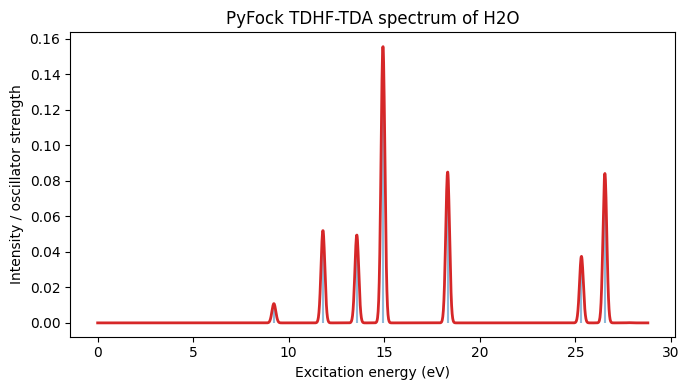

In [24]:
basis_tdhf = Basis(mol_h2o, {"all": Basis.load(mol=mol_h2o, basis_name="def2-SVP")})
# Create a HF object by specifying the functional as "HF"
hf_obj = DFT(mol_h2o, basis_tdhf, xc="HF")
hf_obj.ncores = 2
# Turn DF off as HF currently does not support density fitting
hf_obj.isDF = False 
# Select the 4c2e evaluation engine
hf_obj.rys = True
# Choose from algo 1 or 2
hf_obj.coul_algo = 1
# Choose b/w direct SCF or storing all 4c2e ERIs in memory
hf_obj.direct_scf = False
# Choose b/w SAO or CAO basis
hf_obj.sao = False
# Run HF SCF
energy_hf, dmat_hf = hf_obj.scf()
print("HF energy (Ha):", energy_hf)

C = hf_obj.mo_coefficients
eo = hf_obj.mo_energies
nocc = mol_h2o.nelectrons // 2
nmo = C.shape[1]
nvir = nmo - nocc
Co = C[:, :nocc]
Cv = C[:, nocc:]
eo_occ = eo[:nocc]
eo_vir = eo[nocc:]

eri_ao = Integrals.rys_4c2e_symm(basis_tdhf)

tmp = np.einsum('uvls,ui->ivls', eri_ao, Co)
tmp = np.einsum('ivls,va->ials', tmp, Cv)
tmp = np.einsum('ials,lj->iajs', tmp, Co)
eri_iajb = np.einsum('iajs,sb->iajb', tmp, Cv)

tmp = np.einsum('uvls,ui->ivls', eri_ao, Co)
tmp = np.einsum('ivls,vj->ijls', tmp, Co)
tmp = np.einsum('ijls,la->ijas', tmp, Cv)
eri_ijab = np.einsum('ijas,sb->ijab', tmp, Cv)

A = np.zeros((nocc * nvir, nocc * nvir))
for i in range(nocc):
    for a in range(nvir):
        ia = i * nvir + a
        for j in range(nocc):
            for b in range(nvir):
                jb = j * nvir + b
                A[ia, jb] = 2.0 * eri_iajb[i, a, j, b] - eri_ijab[i, j, a, b]
                if i == j and a == b:
                    A[ia, jb] += eo_vir[a] - eo_occ[i]

exc_au, eigvecs = np.linalg.eigh(A)
hartree_to_ev = 27.2114
exc_ev = exc_au * hartree_to_ev

dip_ao = Integrals.dipole_moment_mat_symm(basis_tdhf)
dip_mo_ia = np.einsum('xmn,mi,na->xia', dip_ao, Co, Cv).reshape(3, nocc * nvir)

osc = []
for s in range(len(exc_au)):
    tdm = dip_mo_ia @ eigvecs[:, s]
    osc.append((2.0 / 3.0) * exc_au[s] * np.dot(tdm, tdm))
osc = np.asarray(osc)

print("First 10 TDHF-TDA excitation energies (eV)")
for i in range(min(10, len(exc_ev))):
    print(f"State {i+1:2d}: {exc_ev[i]:9.4f} eV   f = {osc[i]:.6f}")

import matplotlib.pyplot as plt
if plt is not None:
    x = np.linspace(0.0, max(12.0, exc_ev[:10].max() + 1.0), 2000)
    sigma = 0.10
    spectrum = np.zeros_like(x)
    for e, f in zip(exc_ev[:10], osc[:10]):
        spectrum += f * np.exp(-0.5 * ((x - e) / sigma) ** 2)
    plt.figure(figsize=(7, 4))
    for e, f in zip(exc_ev[:10], osc[:10]):
        plt.vlines(e, 0.0, f, color="tab:blue", alpha=0.5)
    plt.plot(x, spectrum, color="tab:red", lw=2)
    plt.xlabel("Excitation energy (eV)")
    plt.ylabel("Intensity / oscillator strength")
    plt.title("PyFock TDHF-TDA spectrum of H2O")
    plt.tight_layout()
    plt.show()
else:
    print("matplotlib is not available, so the spectrum plot was skipped.")

## 17. Summary

After working through this notebook, you should now be familiar with:

- creating molecules and basis sets in PyFock,
- loading built-in and custom basis sets,
- evaluating one-electron and electron-repulsion integrals,
- using XC grids and AO values,
- running DFT calculations with PyFock defaults and optional advanced settings,
- switching to PySCF grids, LibXC, GPU acceleration, and SAOs when needed,
- exporting densities and orbitals,
- computing fast analytical forces (with a numerical finite-difference cross-check),
- using the ASE calculator for geometry optimization,
- building a simple TDHF-TDA excitation spectrum.